## Part 3: Advanced Text Processing - LDA and BERTopic Topic Modeling (20 pts)

**Resources:**
- LDA:
    - https://medium.com/sayahfares19/text-analysis-topic-modelling-with-spacy-gensim-4cd92ef06e06 
    - https://www.kaggle.com/code/faressayah/text-analysis-topic-modeling-with-spacy-gensim#%F0%9F%93%9A-Topic-Modeling (code for previous post)
    - https://towardsdatascience.com/topic-modelling-in-python-with-spacy-and-gensim-dc8f7748bdbf/ 
- BERTopic:
    - https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_documents.html#visualize-documents-with-plotly 
    - https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_topics.html 


In [1]:
import spacy 
spacy.cli.download("en_core_web_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 68.8 MB/s  0:00:00m0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from spacy import displacy
from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from sklearn.feature_extraction.text import CountVectorizer
import pyLDAvis.gensim_models
from gensim.corpora.dictionary import Dictionary

/home/jovyan/.local/share/envs/sotu/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [6]:
nlp = spacy.load("en_core_web_sm")

In [7]:
sou = pd.read_csv("data/SOTU.csv")

## LDA

In [12]:
def preprocess_text(text): 
    doc = nlp(text) 
    return [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and not token.is_space and len(token.lemma_) > 3]

In [13]:
# Process all texts - note this takes ~ 5 minutes to run
processed_docs = sou['Text'].apply(preprocess_text)

In [15]:
# Build dictionary
dictionary = Dictionary(processed_docs) 
dictionary.filter_extremes(no_below=5, no_above=0.5) # Filter rare/common words 
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

In [16]:
# train LDA model with 18 topics
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=18, random_state=42, passes=10)

In [18]:
# print the top 10 words for each topic
print("\n--- LDA Topics ---") 
for idx, topic in lda_model.print_topics(-1): 
    print(f"Topic: {idx} \nWords: {topic}\n")


--- LDA Topics ---
Topic: 0 
Words: 0.004*"cent" + 0.004*"june" + 0.004*"gold" + 0.003*"island" + 0.003*"silver" + 0.003*"bond" + 0.003*"method" + 0.003*"convention" + 0.003*"indian" + 0.003*"note"

Topic: 1 
Words: 0.008*"depression" + 0.007*"program" + 0.007*"recovery" + 0.006*"budget" + 0.006*"unemployment" + 0.006*"loan" + 0.006*"activity" + 0.006*"farm" + 0.005*"emergency" + 0.005*"cent"

Topic: 2 
Words: 0.008*"dictator" + 0.005*"expression" + 0.004*"british" + 0.004*"1914" + 0.003*"impressive" + 0.003*"actual" + 0.003*"revolution" + 0.003*"schedule" + 0.003*"continent" + 0.003*"partisanship"

Topic: 3 
Words: 0.008*"forest" + 0.007*"corporation" + 0.005*"judge" + 0.005*"wrong" + 0.005*"interstate" + 0.004*"employee" + 0.003*"bureau" + 0.003*"body" + 0.003*"mountain" + 0.003*"island"

Topic: 4 
Words: 0.017*"program" + 0.014*"soviet" + 0.009*"1980" + 0.009*"u.s." + 0.008*"area" + 0.007*"major" + 0.006*"goal" + 0.006*"commitment" + 0.006*"challenge" + 0.006*"nuclear"

Topic: 5 
W

In [20]:
# print the topic distribution for the first speech
first_speech_topics = lda_model.get_document_topics(corpus[0])
print(first_speech_topics)

[(11, np.float32(0.99942815))]


In [19]:
# make a visualization using pyLDAvis
pyLDAvis.enable_notebook()
pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.124490 -0.021460       1        1  25.618865
6     -0.177721  0.042077       2        1  19.985555
5      0.215260  0.071386       3        1   9.897830
7      0.135347 -0.070053       4        1   9.755686
8     -0.048065 -0.119211       5        1   7.285634
17    -0.174387  0.056450       6        1   5.731789
13    -0.173280  0.057692       7        1   5.118534
9     -0.065566 -0.065617       8        1   3.674214
11     0.221114  0.096518       9        1   3.313790
12     0.108985 -0.107040      10        1   3.209760
4      0.170987 -0.059934      11        1   2.417563
3     -0.048335 -0.061174      12        1   1.964851
1      0.001805 -0.137938      13        1   1.024339
14     0.149811  0.117592      14        1   0.773147
15    -0.097709  0.071397      15        1   0.174832
2     -0.030759  0.033480      16        1   0.045779
10    -0.027617  0.048256      17        1   0.003916
16    -0.035383  0.047579      18        1   0.003916, topic_info=           Term         Freq        Total Category  logprob  loglift
509     program  1272.000000  1272.000000  Default  30.0000  30.0000
978      mexico   852.000000   852.000000  Default  29.0000  29.0000
31    americans   990.000000   990.000000  Default  28.0000  28.0000
5330    article   492.000000   492.000000  Default  27.0000  27.0000
666     tonight   666.000000   666.000000  Default  26.0000  26.0000
...         ...          ...          ...      ...      ...      ...
3221     method     0.007818   526.091598  Topic18  -7.4658  -0.9690
664       today     0.007947   576.799945  Topic18  -7.4494  -1.0446
1148    appoint     0.007382   419.009025  Topic18  -7.5231  -0.7987
31    americans     0.008294   990.446257  Topic18  -7.4067  -1.5426
2624       cent     0.007440   614.024230  Topic18  -7.5154  -1.1731

[1282 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
4847      4  0.881725  --the
4847      8  0.080157  --the
3170      1  0.132801   11th
3170      2  0.079680   11th
3170      6  0.292162   11th
...     ...       ...    ...
744       9  0.116620  young
744      10  0.003239  young
744      11  0.016197  young
744      12  0.009718  young
744      14  0.009718  young

[5615 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 7, 6, 8, 9, 18, 14, 10, 12, 13, 5, 4, 2, 15, 16, 3, 11, 17])

## BERTopic

In [8]:
docs = sou['Text'].to_list()

In [9]:
# train the model - this takes about 30 seconds
vectorizer_model = CountVectorizer(stop_words="english")

topic_model = BERTopic(min_topic_size=3)

topics, probs = topic_model.fit_transform(docs)

topic_model.update_topics(docs, vectorizer_model=vectorizer_model)
# remove stop words from the topics (Hint: use CountVectorizer and then .update_topics on topic_model)

In [10]:
# output the top 10 words for each topic
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,54,-1_government_states_united_congress,"[government, states, united, congress, year, p...",[\nFellow Citizens of the Senate and of the Ho...
1,0,28,0_world_new_people_years,"[world, new, people, years, america, american,...","[\nMr. Speaker, Mr. President, my colleagues i..."
2,1,23,1_states_government_united_congress,"[states, government, united, congress, public,...",[\nThe relations of the United States with all...
3,2,18,2_government_public_congress_great,"[government, public, congress, great, national...",[\nTo the Senate and House of Representatives:...
4,3,16,3_states_government_united_public,"[states, government, united, public, congress,...",[\nTo the Senate and House of Representatives ...
5,4,13,4_government_states_united_year,"[government, states, united, year, congress, l...",[\nTo the Senate and House of Representatives:...
6,5,11,5_america_american_americans_tonight,"[america, american, americans, tonight, people...","[\nMr. Speaker, Mr. Vice President, Members of..."
7,6,11,6_world_nations_soviet_peace,"[world, nations, soviet, peace, economic, free...","[\nMr. President, Mr. Speaker, Members of the ..."
8,7,11,7_new_america_americans_american,"[new, america, americans, american, people, to...","[\nMadam Speaker, Mr. Vice President, Members ..."
9,8,7,8_states_government_world_united,"[states, government, world, united, great, sta...","[\nMr. President, Mr. Speaker, Members of the ..."


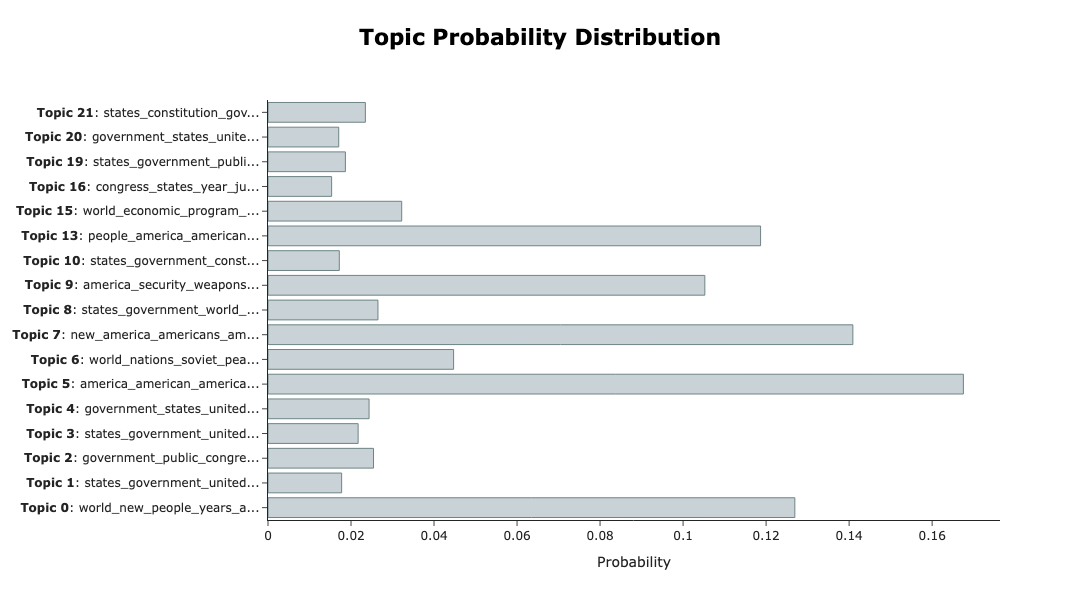

In [12]:
# output the topic distribution for the first speech
# hint: check out approximate_distribution() and visualize_distribution()
topic_dist = topic_model.approximate_distribution(docs)
topic_model.visualize_distribution(topic_dist[0][0])

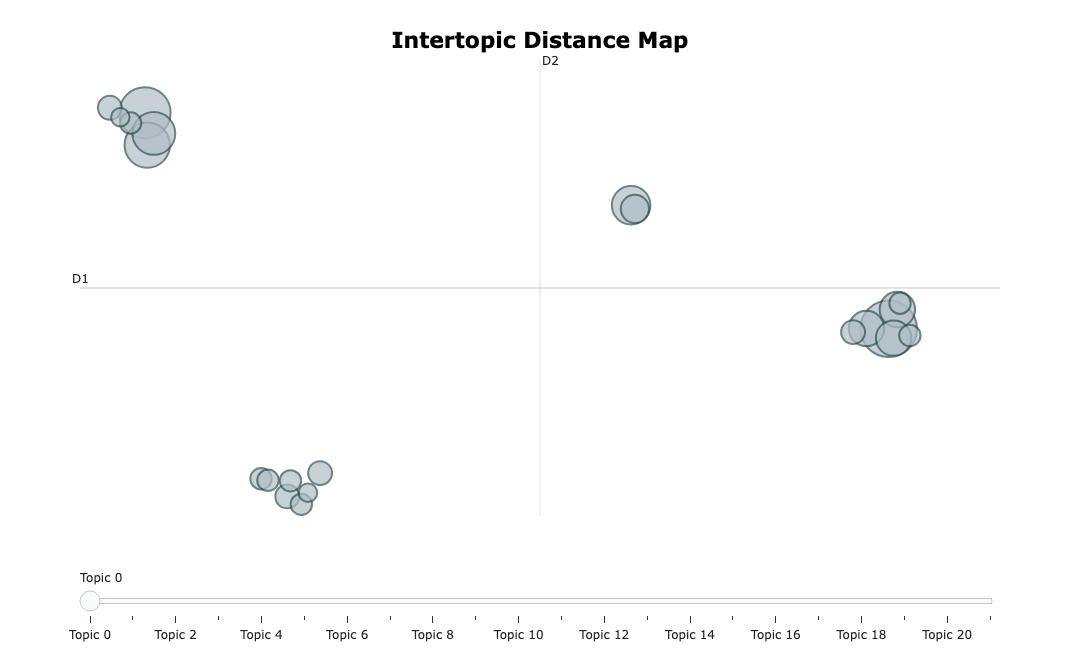

In [13]:
# run this cell to visualize the topics
topic_model.visualize_topics()